<a href="https://colab.research.google.com/github/marcelonicolays/contasRJ/blob/main/compras_diretas_rj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prática em Ciência de dados

Estudo sobre as compras diretas do estado do Rio de Janeiro

Dados disponíveis através do TCERJ,

- https://dados.tcerj.tc.br/api/v1/docs#/Estado/compras_diretas_estado_api_v1_compras_diretas_estado_get


- https://app.powerbi.com/view?r=eyJrIjoiZTYxNzkxN2EtMDAyNC00ZDdjLTk3MzMtM2NkZTJmNDc1MGEwIiwidCI6IjJjYmJlYmU0LTc2MzgtNDYxYi05ZjhjLTE2MmVkZGMzZDBlNCJ9

## Dados entre 2018 e 2022

** Não foi possível extrair para este trabalho, pois são apenas apresentados em PowerBI, porém o response da request apresenta um JSON não estruturado.

** Mantive o codigo que tentava extrair dados em outro notebook apenas para documentação do trabalho.

Importar bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

In [2]:
url = "https://dados.tcerj.tc.br/api/v1/compras_diretas_estado?csv=true"
df = pd.read_csv(url, sep=';', encoding='utf-8')
print(df.head())
print(df.info())

                   Processo  ValorProcesso  \
0  **SEI-120001/009348/2022        10994.0   
1        020002/000001/2024          936.0   
2        020002/000002/2024         3696.0   
3        020002/000003/2024         5040.0   
4        020002/000004/2024         3120.0   

                                              Objeto  \
0  CONTRATAÇÃO DE PESSOA JURÍDICA ESPECIALIADA EM...   
1  PRESTAÇÃO DE SERVIÇOS DE CARÁTER CONTINUADO CO...   
2  GERAMOS O PROCESSO ADMINISTRATIVO PARA O EMPEN...   
3  GERAMOS O PROCESSO ADMINISTRATIVO PARA O EMPEN...   
4  GERAMOS O PROCESSO ADMINISTRATIVO PARA O EMPEN...   

                     Afastamento  AnoProcesso DataAprovacao  \
0    Dispensa - Pequenas Compras         2023    2023-07-05   
1  Inexigibilidade - 14.133/2021         2024    2024-02-08   
2  Inexigibilidade - 14.133/2021         2024    2024-02-08   
3  Inexigibilidade - 14.133/2021         2024    2024-02-08   
4  Inexigibilidade - 14.133/2021         2024    2024-02-08   

       

- Exploração inicial

In [3]:
por_ano = df["AnoProcesso"].value_counts().sort_index()
display(por_ano)
print("\nDimensões do dataset:", df.shape)
print("\nColunas e tipos:\n", df.dtypes)
print("\nValores ausentes por coluna:\n", df.isnull().sum())

,count
AnoProcesso,
2023,6920
2024,6758
2025,4368
2026,1630



Dimensões do dataset: (19676, 13)

Colunas e tipos:
 Processo               object
ValorProcesso         float64
Objeto                 object
Afastamento            object
AnoProcesso             int64
DataAprovacao          object
EnquadramentoLegal     object
Unidade                object
FornecedorVencedor     object
Item                   object
Quantidade             object
UnidadeMedida          object
ValorUnitario         float64
dtype: object

Valores ausentes por coluna:
 Processo              0
ValorProcesso         0
Objeto                1
Afastamento           0
AnoProcesso           0
DataAprovacao         0
EnquadramentoLegal    0
Unidade               0
FornecedorVencedor    0
Item                  0
Quantidade            0
UnidadeMedida         0
ValorUnitario         0
dtype: int64


## Análise inicial
Percebemos que carregou os dados corretamente, com 19676 linhas e 13 colunas, sendo apenas um dado com ausência de informação (Objeto).

A base apresenta boa qualidade estrutural, poucos valores ausentes e grande potencial analítico. Os dados permitem investigar padrões de gastos públicos, concentração de fornecedores e comportamento das compras diretas no Estado do Rio de Janeiro.

- Limpeza e tratamento dos dados

In [4]:
# Criar cópia para preservar base original
df_limpo = df.copy()

# ----------------------------------------------------------
# 1. Remover espaços extras nos nomes das colunas
# ----------------------------------------------------------
df_limpo.columns = df_limpo.columns.str.strip()

# ----------------------------------------------------------
# 2. Remover espaços extras em colunas texto
# ----------------------------------------------------------
colunas_texto = df_limpo.select_dtypes(include='object').columns

for col in colunas_texto:
    df_limpo[col] = df_limpo[col].astype(str).str.strip()

# ----------------------------------------------------------
# 3. Substituir strings vazias por NaN
# ----------------------------------------------------------

df_limpo.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# ----------------------------------------------------------
# 4. Ajustar tipos de dados
# ----------------------------------------------------------

# Datas
df_limpo['DataAprovacao'] = pd.to_datetime(
    df_limpo['DataAprovacao'],
    errors='coerce'
)

# Numéricas
df_limpo['ValorProcesso'] = pd.to_numeric(
    df_limpo['ValorProcesso'],
    errors='coerce'
)

df_limpo['ValorUnitario'] = pd.to_numeric(
    df_limpo['ValorUnitario'],
    errors='coerce'
)

df_limpo['AnoProcesso'] = pd.to_numeric(
    df_limpo['AnoProcesso'],
    errors='coerce'
).astype('Int64')

df_limpo['Quantidade'] = (
    df_limpo['Quantidade']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_limpo['Quantidade'] = pd.to_numeric(
    df_limpo['Quantidade'],
    errors='coerce'
)

# ----------------------------------------------------------
# 5. Verificar registros duplicados e sem processo
# ----------------------------------------------------------
duplicados = df_limpo[df_limpo.duplicated()]

print(f"Quantidade de linhas duplicadas: {duplicados.shape[0]}")

# Mostrar alguns exemplos
display(duplicados.head())

sem_processo = df_limpo[df_limpo['Processo'].isnull()]

print(f"\nLinhas sem 'Processo': {sem_processo.shape[0]}")

# Mostrar exemplos
display(sem_processo)

# Preencher Objeto ausente
df_limpo['Objeto'] = df_limpo['Objeto'].fillna('Não informado')

print("Dataset limpo")
print("\nResumo da limpeza:")
print(f"Total removido: {df.shape[0] - df_limpo.shape[0]}")
print("\nValores ausentes após tratamento:")
print(df_limpo.isnull().sum())

Quantidade de linhas duplicadas: 43


,Processo,ValorProcesso,Objeto,Afastamento,AnoProcesso,DataAprovacao,EnquadramentoLegal,Unidade,FornecedorVencedor,Item,Quantidade,UnidadeMedida,ValorUnitario
2610,SEI-040014/024431/2024,12705.00,TRATA-SE DA REALIZAÇÃO DE INSCRIÇÕES DE SERVID...,Inexigibilidade - 14.133/2021,2024,2024-07-01,"Lei nº 14.133/2021, Art. 74º, III, f",RIOPREVIDÊNCIA - FUNDO UNICO DE PREVIDENCIA SO...,INSTITUTO BRASILEIRO DE ATUÁRIA,CAPACITACAO E TREINAMENTO DE PESSOAL - DESCRIC...,1.0,SERVICO,6352.50
3552,SEI-070002/013185/2023,3050.00,INSCRIÇÃO DE SERVIDOR NA SEMANA DE BARRAGENS 2...,Inexigibilidade - Lei 8.666,2023,2023-08-24,Lei 8.666/93.,INEA - INSTITUTO ESTADUAL DO AMBIENTE,COMITE BRASILEIRO DE BARRAGENS,PARTICIPACAO EM CONGRESSOS / SIMPOSIO - DESCRI...,1.0,VAGA,1525.00
4305,SEI-080002/000752/1/2024,3349888.16,CONTRATAÇÃO DE EMPRESA ESPECIALIZADA PARA A CO...,Dispensa de Licitação,2024,2024-07-31,"Lei nº 14.133/2021, Art. 75º, VIII",FSERJ - FUNDAÇÃO SAÚDE DO EST. DO RIO DE JANEIRO,PALMAR LABORATORIO DE ANALISE CLINICAS LTDA,SERVICOS DE EXAMES LABORATORIAIS - DESCRIÇÃO: ...,1.0,UN,837472.04
4306,SEI-080002/000752/1/2024,3349888.16,CONTRATAÇÃO DE EMPRESA ESPECIALIZADA PARA A CO...,Dispensa de Licitação,2024,2024-07-31,"Lei nº 14.133/2021, Art. 75º, VIII",FSERJ - FUNDAÇÃO SAÚDE DO EST. DO RIO DE JANEIRO,PALMAR LABORATORIO DE ANALISE CLINICAS LTDA,SERVICOS DE EXAMES LABORATORIAIS - DESCRIÇÃO: ...,1.0,UN,837472.04
4307,SEI-080002/000752/1/2024,3349888.16,CONTRATAÇÃO DE EMPRESA ESPECIALIZADA PARA A CO...,Dispensa de Licitação,2024,2024-07-31,"Lei nº 14.133/2021, Art. 75º, VIII",FSERJ - FUNDAÇÃO SAÚDE DO EST. DO RIO DE JANEIRO,PALMAR LABORATORIO DE ANALISE CLINICAS LTDA,SERVICOS DE EXAMES LABORATORIAIS - DESCRIÇÃO: ...,1.0,UN,837472.04



Linhas sem 'Processo': 0


,Processo,ValorProcesso,Objeto,Afastamento,AnoProcesso,DataAprovacao,EnquadramentoLegal,Unidade,FornecedorVencedor,Item,Quantidade,UnidadeMedida,ValorUnitario


Dataset limpo

Resumo da limpeza:
Total removido: 0

Valores ausentes após tratamento:
Processo              0
ValorProcesso         0
Objeto                0
Afastamento           0
AnoProcesso           0
DataAprovacao         0
EnquadramentoLegal    0
Unidade               0
FornecedorVencedor    0
Item                  0
Quantidade            0
UnidadeMedida         0
ValorUnitario         0
dtype: int64


Durante a etapa de limpeza, foram identificados registros aparentemente duplicados. Contudo, após inspeção manual, verificou-se que esses casos representavam itens legítimos fracionados dentro do mesmo processo administrativo, e não erros de duplicidade.

Por esse motivo, optou-se por não excluir registros duplicados automaticamente, preservando a integridade analítica da base.

- Análise exploratória

In [5]:
total_compras_df_limpo = (
    df_limpo[
        ['Processo', 'ValorProcesso']
    ]
    .drop_duplicates(subset='Processo') #Considerar apenas um valor de processo.
    ['ValorProcesso']
    .sum()
)

print("Dimensão após limpeza:", df_limpo.shape)
print("\nTipos de dados ajustados:")
print(df_limpo.dtypes)
print("\nValores ausentes após tratamento:")
print(df_limpo.isnull().sum())
print("\nEstatísticas descritivas (numéricas):\n", df_limpo.describe())
print("\nTotal em Compras diretas: ")
print(f"R$ {total_compras_df_limpo:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))


Dimensão após limpeza: (19676, 13)

Tipos de dados ajustados:
Processo                      object
ValorProcesso                float64
Objeto                        object
Afastamento                   object
AnoProcesso                    Int64
DataAprovacao         datetime64[ns]
EnquadramentoLegal            object
Unidade                       object
FornecedorVencedor            object
Item                          object
Quantidade                   float64
UnidadeMedida                 object
ValorUnitario                float64
dtype: object

Valores ausentes após tratamento:
Processo              0
ValorProcesso         0
Objeto                0
Afastamento           0
AnoProcesso           0
DataAprovacao         0
EnquadramentoLegal    0
Unidade               0
FornecedorVencedor    0
Item                  0
Quantidade            0
UnidadeMedida         0
ValorUnitario         0
dtype: int64

Estatísticas descritivas (numéricas):
        ValorProcesso  AnoProcesso          

### Análise da exploração inicial

1. Distribuição Assimétrica

As variáveis monetárias apresentam forte assimetria positiva:

poucos contratos extremamente altos;
muitos contratos de menor valor.

Isso é evidenciado pela diferença entre média e mediana.

2. Quantidades Concentradas em Pequenos Volumes

Apesar da média de quantidade ser elevada, a mediana igual a 2 unidades indica que a maioria das compras envolve poucos itens, enquanto alguns registros com quantidades muito grandes elevam a média.

3. Série Temporal Atualizada

Os dados abrangem processos entre:

- 2023
- 2026

com registros até 04/06/2026, mostrando base atualizada.

Total de gastos em compras diretas de R$ 17.031.717.875,97.

## Manipulação e análise dos dados

### Filtragem de Compras de Alto Valor

In [6]:
compras_altas = (
    df_limpo[df_limpo['ValorProcesso'] > 10000000]
    .sort_values(by='ValorProcesso', ascending=False)
)
pd.options.display.float_format = '{:,.2f}'.format

total_compras_altas = (
    compras_altas[
        ['Processo', 'ValorProcesso']
    ]
    .drop_duplicates(subset='Processo')
    ['ValorProcesso']
    .sum()
)

print("Quantidade de compras acima de R$ 10 milhões:")
print(compras_altas.shape[0])
print("\nQuantidade de processos únicos:")
print(compras_altas['Processo'].nunique())
print("\nValor total das compras altas (sem duplicidade):")
print(f"R$ {total_compras_altas:,.2f}")

compras_altas[
    [
        'Processo',
        'Unidade',
        'FornecedorVencedor',
        'Item',
        'Quantidade',
        'ValorUnitario',
        'ValorProcesso'
    ]
].head(20)

Quantidade de compras acima de R$ 10 milhões:
579

Quantidade de processos únicos:
321

Valor total das compras altas (sem duplicidade):
R$ 10,573,341,938.64


,Processo,Unidade,FornecedorVencedor,Item,Quantidade,ValorUnitario,ValorProcesso
7301,SEI-140001/078164/2024,SETRANS - SECRETARIA DE ESTADO DE TRANSPORTES,PY13 PARTICIPACOES S.A,PERMISSAO DE USO DE IMOVEL - DESCRICAO: OUTORG...,1.00,"660,000,000.00","660,000,000.00"
1768,SEI-030001/103373/A/2024,SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,EUREKA SOLUCOES PEDAGOGICAS LTDA,LIVRO DIDATICO - TITULO: ENSINO MEDIO EM FOCO ...,"141,612.00",582.83,"334,336,436.93"
1769,SEI-030001/103373/A/2024,SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,EUREKA SOLUCOES PEDAGOGICAS LTDA,LIVRO DIDATICO - TITULO: ENSINO MEDIO EM FOCO ...,"124,030.00",582.83,"334,336,436.93"
1770,SEI-030001/103373/A/2024,SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,EUREKA SOLUCOES PEDAGOGICAS LTDA,LIVRO DIDATICO - TITULO: COLECAO LITERATURA A ...,"189,617.00",363.88,"334,336,436.93"
1767,SEI-030001/103373/A/2024,SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,EUREKA SOLUCOES PEDAGOGICAS LTDA,LIVRO DIDATICO - TITULO: ENSINO MEDIO EM FOCO ...,"189,617.00",582.83,"334,336,436.93"
7634,SEI-150016/022951/2024,DETRAN - DEPARTAMENTO DE TRÂNSITO DO ESTADO DO RJ,COMÉRCIO IMPORTAÇÃO E EXPORTAÇÃO 3 IRMÃOS LTDA,LOCACAO DE IMOVEL - DESCRICAO: CONTRATACAO DE...,1.00,"267,137,176.26","267,137,176.26"
3768,SEI-080001/002641/G/2022,FES - FUNDO ESTADUAL DE SAÚDE,INSTITUTO DE DESENVOLVIMENTO ENSINO E ASSISTÊN...,SERVICO MEDICO-HOSPITALAR - DESCRIÇÃO: CONTRAT...,12.00,"19,479,218.84","233,750,626.08"
3963,SEI-080001/025088/2021,FES - FUNDO ESTADUAL DE SAÚDE,INSTITUTO DE DESENVOLVIMENTO ENSINO E ASSISTÊN...,SERVICO MEDICO-HOSPITALAR - DESCRIÇÃO: CONTRAT...,15.00,"14,249,463.01","213,741,945.15"
3966,SEI-080001/025088C/2021,FES - FUNDO ESTADUAL DE SAÚDE,INSTITUTO DE DESENVOLVIMENTO ENSINO E ASSISTÊN...,SERVICO MEDICO-HOSPITALAR - DESCRIÇÃO: CONTRAT...,12.00,"15,993,672.60","191,924,071.20"
2457,SEI-030029/015972/2023,SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,EDITORA ROCCO LTDA,"LIVRO DIDATICO - TITULO: FALA SERIO, MAE!, AUT...","16,694.00",59.90,"178,097,063.55"


Foram identificados 579 registros de compras diretas superiores a R\$ 10 milhões, correspondendo a 321 processos únicos, após desconsiderar repetições do mesmo processo em múltiplas linhas.

O valor total dessas contratações alcançou aproximadamente R\$ 10,57 bilhões, demonstrando forte concentração de recursos em um número reduzido de processos, já que o total em compras diretas foi de R\$ 17.031.717.875,97., representando mais de 60% dos gastos.

Observou-se variedade de objetos contratados, incluindo educação, saúde, serviços continuados e patrimônio público. Entre os casos encontrados, destaca-se aluguel de imóvel no valor de R\$ 267.137.176,26, curiosamente não encontrei noticia nos grandes portais sobre despesa neste montante.

Entrada recente de despesa de R$ 660 Milhões referente à despesas com licitação de sistema de transportes públicos.

Os resultados indicam que uma parcela reduzida de processos concentra grande parte dos recursos públicos analisados.

## Órgãos que Mais Gastaram (GroupBy)

In [7]:
gastos_orgao = (
    df_limpo
    .drop_duplicates(subset='Processo')  # remove repetição do processo
    .groupby('Unidade')['ValorProcesso']
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 órgãos que mais gastaram:")
gastos_orgao.head(10)

Top 10 órgãos que mais gastaram:


,ValorProcesso
Unidade,
FSERJ - FUNDAÇÃO SAÚDE DO EST. DO RIO DE JANEIRO,"3,507,119,674.66"
FES - FUNDO ESTADUAL DE SAÚDE,"3,175,167,747.92"
SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,"2,188,471,695.87"
UERJ - ADMINISTRACAO CENTRAL,"1,635,548,493.60"
DER-RJ - FUND DEP ESTRADAS DE RODAGEM DO ESTADO DO RJ,"870,187,606.32"
SETRANS - SECRETARIA DE ESTADO DE TRANSPORTES,"668,293,465.91"
DETRAN - DEPARTAMENTO DE TRÂNSITO DO ESTADO DO RJ,"623,589,845.34"
FUNARJ - FUND ANITA MANTUANO DE ARTES DO EST DO RJ,"347,539,989.06"
INEA - INSTITUTO ESTADUAL DO AMBIENTE,"321,431,075.98"


A análise evidencia que os gastos com compras diretas estão fortemente concentrados em áreas estratégicas do governo estadual, especialmente saúde e educação, que juntas representam parcela significativa do volume financeiro total. Essa distribuição é coerente com a natureza dessas áreas, que demandam contratos contínuos e de grande escala para garantir o funcionamento adequado dos serviços públicos.

Adicionalmente, observou-se que, no âmbito do Departamento de Trânsito do Estado do Rio de Janeiro, o aluguel do prédio central representa mais de 40% dos gastos em compras diretas da unidade, evidenciando uma forte concentração de despesas em custos de infraestrutura física. Esse resultado indica que uma parcela relevante do orçamento do órgão está comprometida com despesas administrativas recorrentes, em detrimento de outros possíveis investimentos operacionais.

## Ranking de Fornecedores

In [8]:
ranking_fornecedores = (
    df_limpo
    .drop_duplicates(subset='Processo')# remove repetição do processo
    .groupby('FornecedorVencedor')['ValorProcesso']
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 fornecedores:")
ranking_fornecedores.head(10)

Top 10 fornecedores:


,ValorProcesso
FornecedorVencedor,
UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,"1,358,608,274.48"
INSTITUTO DE DESENVOLVIMENTO ENSINO E ASSISTÊNCIA A SAÚDE - IDEAS,"855,923,442.79"
PY13 PARTICIPACOES S.A,"660,000,000.00"
EUREKA SOLUCOES PEDAGOGICAS LTDA,"556,948,085.33"
LIGHT SERVICOS DE ELETRICIDADE SA,"537,033,644.77"
TUISE REPRESENTAÇÃO COMERCIAL LTDA,"432,024,134.63"
ECO RIO COMERCIO E SERVIÇOS GERAIS LTDA,"322,677,174.48"
COMÉRCIO IMPORTAÇÃO E EXPORTAÇÃO 3 IRMÃOS LTDA,"267,611,952.41"
AMPLA ENERGIA E SERVIÇOS S/A,"261,812,589.26"


A análise revela uma estrutura de contratação concentrada, com predominância de fornecedores ligados às áreas de saúde, educação e serviços essenciais. Essa configuração é coerente com as demandas do setor público, mas também evidencia a importância de monitoramento contínuo quanto à concentração de fornecedores e à diversificação das contratações.

## Evolução Temporal dos Gastos



/tmp/ipykernel_25242/1461774153.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processos_unicos['AnoMes'] = processos_unicos['DataAprovacao'].dt.to_period('M')


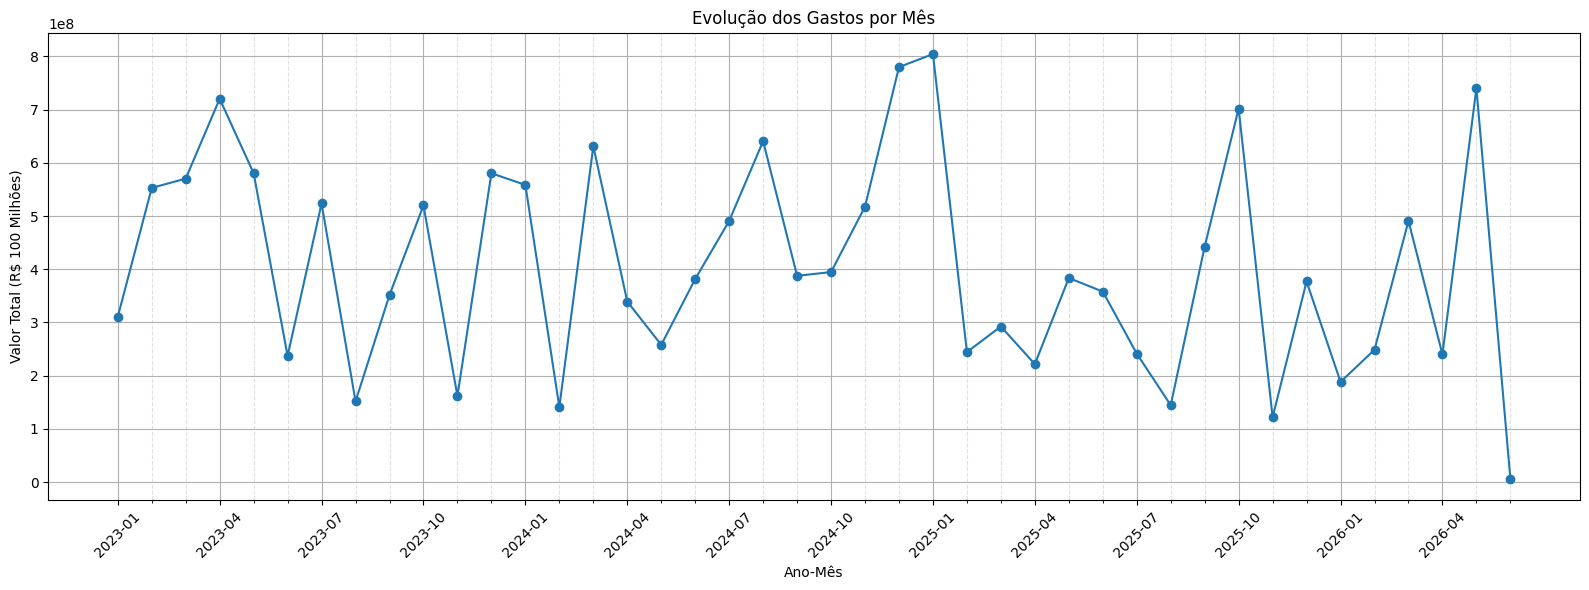

In [9]:
# ---------------------------------------------------
# 1. Garantir processos únicos
# ---------------------------------------------------
processos_unicos = df_limpo.drop_duplicates(subset='Processo')

# ---------------------------------------------------
# 2. Criar coluna Ano-Mês
# ---------------------------------------------------
processos_unicos['AnoMes'] = processos_unicos['DataAprovacao'].dt.to_period('M')

# ---------------------------------------------------
# 3. Agrupar por mês
# ---------------------------------------------------
gastos_mes = (
    processos_unicos
    .groupby('AnoMes')['ValorProcesso']
    .sum()
    .sort_index()
)

# Converter índice para string (melhor para plot)
gastos_mes.index = gastos_mes.index.astype(str)

# ---------------------------------------------------
# 4. Plotar gráfico de linha
# ---------------------------------------------------
plt.figure(figsize=(16,6))

plt.plot(gastos_mes.index, gastos_mes.values, marker='o')

# -------------------------------
# Eixo X
# -------------------------------

# Ticks principais (rótulos a cada 3 meses)
plt.xticks(
    ticks=range(0, len(gastos_mes), 3),
    labels=gastos_mes.index[::3],
    rotation=45
)

# Ticks secundários (todos os meses)
ax = plt.gca()
ax.set_xticks(np.arange(len(gastos_mes)), minor=True)

# -------------------------------
# Grade (grid)
# -------------------------------

# Grade principal (mais forte)
ax.grid(True, which='major', linestyle='-')

# Grade mensal (mais leve)
ax.grid(True, which='minor', linestyle='--', alpha=0.4)

# -------------------------------
# Títulos
# -------------------------------

plt.title('Evolução dos Gastos por Mês')
plt.xlabel('Ano-Mês')
plt.ylabel('Valor Total (R$ 100 Milhões)')

plt.tight_layout()
plt.show()

Verificam-se oscilações ao longo dos meses nos gastos com compras diretas, sem um padrão linear bem definido. A maior parte dos períodos apresenta valores dentro de uma faixa relativamente estável, enquanto poucos meses registram gastos mais elevados, ultrapassando R\$ 700 milhões.

Esses picos indicam momentos pontuais de maior concentração de contratações, possivelmente associados à execução de contratos de grande porte ou a períodos específicos do ciclo orçamentário.

## Detetcção preço por item.

In [10]:
# média e desvio por item
estatisticas = (
    df_limpo
    .groupby('Item')['ValorUnitario']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

# juntar ao dataframe
df_analise = df_limpo.merge(
    estatisticas,
    on='Item',
    how='left'
)

# calcular z-score
df_analise['std'] = df_analise['std'].replace(0, np.nan)

df_analise['zscore_preco'] = (
    (df_analise['ValorUnitario'] - df_analise['mean'])
    / df_analise['std']
)

df_analise['zscore_preco'] = (
    df_analise['zscore_preco']
    .replace([np.inf, -np.inf], np.nan)
)

# suspeito quando zscore > 3
df_analise['SuspeitoPreco'] = np.where(
    df_analise['zscore_preco'] > 3,
    1,
    0
)

# mostrar maiores suspeitas
suspeitos = df_analise.sort_values(
    by='zscore_preco',
    ascending=False
)

suspeitos[
    [
        'Item',
        'FornecedorVencedor',
        'ValorUnitario',
        'mean',
        'zscore_preco'
    ]
].head(20)

,Item,FornecedorVencedor,ValorUnitario,mean,zscore_preco
7468,SERVICO DE PRODUCAO ARTISTICA - DESCRICAO: CON...,BONUS TRACK ENTRETENIMENTO LTDA,"15,000,000.00","108,130.20",28.86
8245,SERVICO DE PRODUCAO ARTISTICA - DESCRICAO: CON...,BONUS TRACK ENTRETENIMENTO LTDA,"10,000,000.00","108,130.20",19.17
10495,SERVICO DE FORNECIMENTO DE AGUA E COLETA DE ES...,F AB ZONA OESTE S A,"49,531,444.05","692,439.38",14.34
7481,PARTICIPACAO EM CONGRESSOS / SIMPOSIO - DESCRI...,"LAVORO GERENCIAMENTO EMPRESARIAL, CORPORATIVO ...","86,900.00","4,211.33",13.31
9317,SERVICO DE PRODUCAO ARTISTICA - DESCRICAO: CON...,LIGA DAS ESCOLAS DE SAMBA DO RIO DE JANEIRO - ...,"6,500,000.00","108,130.20",12.39
9318,SERVICO DE PRODUCAO ARTISTICA - DESCRICAO: CON...,LIGA INDEPENDENTE DO GRUPO A - RIO DE JANEIRO,"6,500,000.00","108,130.20",12.39
2364,SERVICO DE FORNECIMENTO DE AGUA - DESCRIÇÃO: C...,AGUAS DO RIO 4 SPE S.A,"34,401,406.91","655,885.02",11.90
1461,SERVICO DE FORNECIMENTO DE AGUA - DESCRIÇÃO: C...,AGUAS DO RIO 4 SPE S.A,"33,440,197.32","655,885.02",11.56
15260,PARTICIPACAO EM SEMINARIOS - DESCRIÇÃO: INSCRI...,ORZIL CONSULTORIA E TREINAMENTO LTDA EPP,"101,995.20","4,087.01",10.70
7535,SERVICOS DE ORGANIZACAO DE EVENTOS - DESCRIÇÃO...,ONIX ORGANIZACAO E PRODUCAO DE EVENTOS LTDA,"14,000,000.00","791,430.84",9.77


 - O algoritmo detecta anomalias estatísticas, não necessariamente ilegalidades.

# Machine Learnig

## Isolation Forest

In [11]:
features = [
    'ValorProcesso',
    'Quantidade',
    'ValorUnitario'
]

X = df_limpo[features].fillna(0)

modelo_if = IsolationForest(
    contamination=0.02,
    random_state=42
)

df_limpo['Anomalia'] = modelo_if.fit_predict(X)

# -1 = suspeito
suspeitos = df_limpo[df_limpo['Anomalia'] == -1]
print(suspeitos.info())
suspeitos.head(20)

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 139 to 19379
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Processo            389 non-null    object        
 1   ValorProcesso       389 non-null    float64       
 2   Objeto              389 non-null    object        
 3   Afastamento         389 non-null    object        
 4   AnoProcesso         389 non-null    Int64         
 5   DataAprovacao       389 non-null    datetime64[ns]
 6   EnquadramentoLegal  389 non-null    object        
 7   Unidade             389 non-null    object        
 8   FornecedorVencedor  389 non-null    object        
 9   Item                389 non-null    object        
 10  Quantidade          389 non-null    float64       
 11  UnidadeMedida       389 non-null    object        
 12  ValorUnitario       389 non-null    float64       
 13  Anomalia            389 non-null    int64         


,Processo,ValorProcesso,Objeto,Afastamento,AnoProcesso,DataAprovacao,EnquadramentoLegal,Unidade,FornecedorVencedor,Item,Quantidade,UnidadeMedida,ValorUnitario,Anomalia
139,030001/122176/2025,"97,796,253.26",A PRESENTE CONTRATAÇÃO VISA DAR PROSSEGUIMENTO...,Inexigibilidade - 14.133/2021,2025,2025-12-26,"Lei n 14.133/2021, Art. 74, Caput",SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,"FUNDAÇÃO DE APOIO A PESQUISA, ENSINO E ASSISTE...",SERVICO DE AVALIACAO DA QUALIDADE DO ENSINO - ...,1.00,SERVICO,"97,796,253.26",-1
360,330032/001854/2023,"39,821,686.85",OBRAS DE CONTENÇÃO LOCALIZADAS NO KM 02 DA ROD...,Dispensa - Especial,2023,2023-05-30,Considerando a gravidade da situação comprovad...,DER-RJ - FUND DEP ESTRADAS DE RODAGEM DO ESTAD...,CONSTRUTORA MEDEIROS CARVALHO DE ALMEIDA LTDA,SERVICOS EM RODOVIAS - DESCRICAO: CONTRATACAO ...,1.00,SERVICO,"39,821,686.85",-1
503,350208/000080A/2024,"36,000,000.00",PRESTAÇÃO DE SERVIÇOS MÉDICO-HOSPITALARES ESPE...,Inexigibilidade - 14.133/2021,2024,2024-09-11,"Lei nº 14.133/2021, Art. 74º, IV",FUNESPOM - FUNDO ESP. POLÍCIA MILITAR RJ,INSTITUTO HERMES PARDINI S.A.,SERVICO MEDICO-HOSPITALAR - DESCRIÇÃO: CONTRAT...,1.00,SERVICO,"36,000,000.00",-1
643,L5SEI-210098/000688/2022,"640,953.00",CONTRATAÇÃO EMERGENCIAL DE EMPRESA ESPECIALIZA...,Dispensa - Especial,2023,2023-01-17,"art. 24, IV, da Lei nº 8.666/1993.",SEAP - SECRETARIA DE ESTADO DE ADMIN.PENITENCI...,EKO AMBIENTAL SERVIÇOS E EMPREENDIMENTOS LTDA ...,SERVICOS DE COLETA DE LIXO - DESCRICAO: CONTRA...,"1,563,300.00",KG,0.41,-1
1267,SEI-020004/000711/2025,"23,000,000.00",CONTRATACAO DE EMPRESA PARA PRESTACAO DE SERVI...,Inexigibilidade - 13.303/2016,2026,2026-01-06,"Lei 13.303/2016, Art. 30, caput - inexigibilidade",CEASA-RJ - CENTRAIS DE ABASTECIMENTO DO ESTADO...,LIGHT SERVICOS DE ELETRICIDADE SA,FORNECIMENTO DE ENERGIA ELETRICA - DESCRIÇÃO: ...,1.00,SERVICO,"23,000,000.00",-1
1442,SEI-030001/000218/2026,"591,816.00",O OBJETO CONSISTE NA CONTRATAÇÃO DE PRESTAÇÃO ...,Inexigibilidade - 14.133/2021,2026,2026-02-19,"Lei n 14.133/2021, Art. 74, I",SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,SUPERVIA CONCESSIONÁRIA DE TRANSPORTE FERROVI...,SERVICO DE FORNECIMENTO/RECARGA VALE TRANSPORT...,"591,816.00",UN,1.00,-1
1443,SEI-030001/000219/2026,"910,644.00",O SERVIÇO CONSISTE NA CONTRATAÇÃO DE TRANSPORT...,Inexigibilidade - 14.133/2021,2026,2026-04-08,"Lei n 14.133/2021, Art. 74, I",SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,CONCESSÃO METROVIARIA DO RIO DE JANEIRO S.A.,SERVICO DE FORNECIMENTO/RECARGA VALE TRANSPORT...,"910,644.00",UN,1.00,-1
1461,SEI-030001/004862/2026,"33,440,197.32",CONTRATAÇÃO DE EMPRESA PARA PRESTAÇÃO DE SERVI...,Inexigibilidade - 14.133/2021,2026,2026-04-16,"Lei n 14.133/2021, Art. 74, Caput",SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,AGUAS DO RIO 4 SPE S.A,SERVICO DE FORNECIMENTO DE AGUA - DESCRIÇÃO: C...,1.00,SERVICO,"33,440,197.32",-1
1464,SEI-030001/004874/2024,"95,276,130.48",A PRESENTE CONTRATAÇÃO DE INSTITUIÇÃO PARA REA...,Dispensa de Licitação,2024,2024-06-03,"Lei nº 14.133/2021, Art. 75º, XV",SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,"FUNDAÇÃO DE APOIO A PESQUISA, ENSINO E ASSISTE...",SERVICO DE AVALIACAO DA QUALIDADE DO ENSINO - ...,1.00,SERVICO,"95,276,130.48",-1
1471,SEI-030001/004886/2026,"25,008,110.88",CONTRATAÇÃO DE EMPRESA PARA PRESTAÇÃO DE SERVI...,Inexigibilidade - 14.133/2021,2026,2026-04-16,"Lei n 14.133/2021, Art. 74, Caput",SEEDUC - SECRETARIA DE ESTADO DE EDUCAÇÃO,AMPLA ENERGIA E SERVIÇOS S/A,FORNECIMENTO DE ENERGIA ELETRICA - DESCRIÇÃO: ...,1.00,SERVICO,"25,008,110.88",-1


* Processos estatisticamente incomuns em relação ao restante da base.

## Clustering com KMeans + DBSCAN

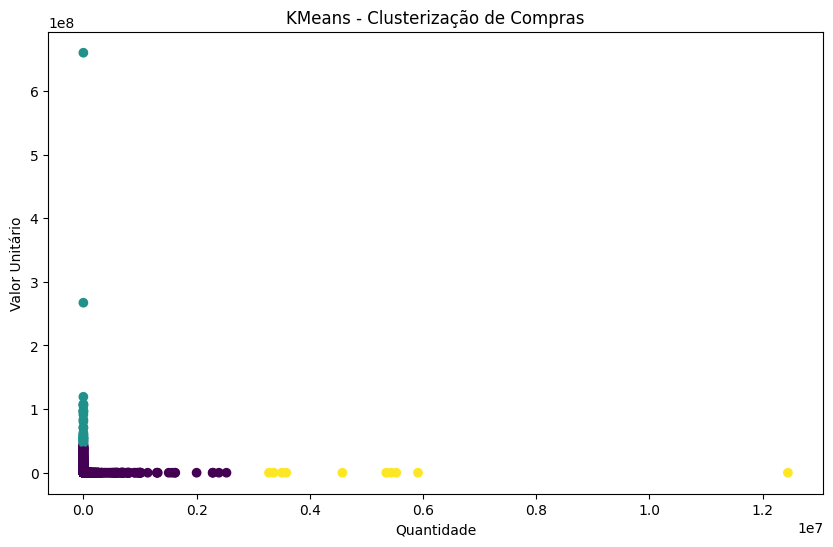

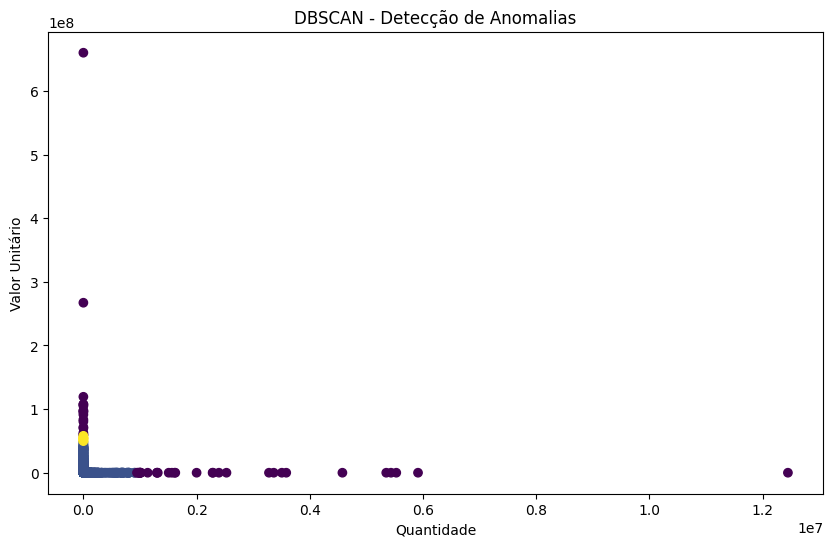

Quantidade de anomalias detectadas:
69


,Processo,FornecedorVencedor,Item,Quantidade,ValorUnitario,ValorProcesso
139,030001/122176/2025,"FUNDAÇÃO DE APOIO A PESQUISA, ENSINO E ASSISTE...",SERVICO DE AVALIACAO DA QUALIDADE DO ENSINO - ...,1.00,"97,796,253.26","97,796,253.26"
643,L5SEI-210098/000688/2022,EKO AMBIENTAL SERVIÇOS E EMPREENDIMENTOS LTDA ...,SERVICOS DE COLETA DE LIXO - DESCRICAO: CONTRA...,"1,563,300.00",0.41,"640,953.00"
1443,SEI-030001/000219/2026,CONCESSÃO METROVIARIA DO RIO DE JANEIRO S.A.,SERVICO DE FORNECIMENTO/RECARGA VALE TRANSPORT...,"910,644.00",1.00,"910,644.00"
1464,SEI-030001/004874/2024,"FUNDAÇÃO DE APOIO A PESQUISA, ENSINO E ASSISTE...",SERVICO DE AVALIACAO DA QUALIDADE DO ENSINO - ...,1.00,"95,276,130.48","95,276,130.48"
1621,SEI-030001/065208/2024,ESTUDO PLAY EDITORA E SOLUÇÕES EDUCACIONAIS LTDA,MATERIAL DIDATICO ESCOLAR - TIPO: COLECAO DIGI...,1.00,"83,414,636.00","83,414,636.00"
1743,SEI-030001/075841/C/2024,AGILE CORP SERVIÇOS ESPECIALIZADOS LTDA,SERVICOS DE LIMPEZA E CONSERVACAO DE AMBIENTE ...,"246,000.00",153.73,"37,817,580.00"
1749,SEI-030001/083332/2024,INSTITUTO DE ENSINO PÓLIS CIVITAS LTDA,CAPACITACAO DE PROFESSORES - DESCRIÇÃO: CONTRA...,"18,125.00","4,000.00","72,500,000.00"
1762,SEI-030001/094868/2024,FUNDAÇÃO GETULIO VARGAS,SERVICO DE APOIO AOS SERVICOS EDUCACIONAIS - ...,1.00,"96,742,700.00","96,742,700.00"
1767,SEI-030001/103373/A/2024,EUREKA SOLUCOES PEDAGOGICAS LTDA,LIVRO DIDATICO - TITULO: ENSINO MEDIO EM FOCO ...,"189,617.00",582.83,"334,336,436.93"
1768,SEI-030001/103373/A/2024,EUREKA SOLUCOES PEDAGOGICAS LTDA,LIVRO DIDATICO - TITULO: ENSINO MEDIO EM FOCO ...,"141,612.00",582.83,"334,336,436.93"


In [12]:
# ------------------------------------------------------------
# 1. Selecionar variáveis
# ------------------------------------------------------------

dados_cluster = df_limpo.copy()

features = [
    'ValorProcesso',
    'Quantidade',
    'ValorUnitario'
]

X = dados_cluster[features].fillna(0)

# ------------------------------------------------------------
# 2. Padronização
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 3. KMEANS
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

dados_cluster['ClusterKMeans'] = kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# 4. DBSCAN
# ------------------------------------------------------------

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

dados_cluster['ClusterDBSCAN'] = dbscan.fit_predict(X_scaled)

# ------------------------------------------------------------
# 5. Visualização KMeans
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    dados_cluster['Quantidade'],
    dados_cluster['ValorUnitario'],
    c=dados_cluster['ClusterKMeans']
)

plt.xlabel('Quantidade')
plt.ylabel('Valor Unitário')
plt.title('KMeans - Clusterização de Compras')

plt.show()

# ------------------------------------------------------------
# 6. Visualização DBSCAN
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    dados_cluster['Quantidade'],
    dados_cluster['ValorUnitario'],
    c=dados_cluster['ClusterDBSCAN']
)

plt.xlabel('Quantidade')
plt.ylabel('Valor Unitário')
plt.title('DBSCAN - Detecção de Anomalias')

plt.show()

# ------------------------------------------------------------
# 7. Exibir possíveis anomalias
# ------------------------------------------------------------
# DBSCAN marca anomalias com -1
# ------------------------------------------------------------

anomalias = dados_cluster[
    dados_cluster['ClusterDBSCAN'] == -1
]

print('Quantidade de anomalias detectadas:')
print(len(anomalias))

anomalias[
    [
        'Processo',
        'FornecedorVencedor',
        'Item',
        'Quantidade',
        'ValorUnitario',
        'ValorProcesso'
    ]
].head(20)

* Separaram em:


1. Pequenas compras administrativas
2. Compras médias
3. Contratos Gigantes

* Localizando registros Outliers

Localizado 69 anomalias


## Random Forest

In [13]:
# ============================================
# CRIAR DATAFRAME PARA MODELAGEM
# ============================================

df_modelo = df.copy()

# ============================================
# AJUSTE DE COLUNAS NUMÉRICAS
# (somente no df_modelo)
# ============================================

colunas_numericas = [
    "ValorProcesso",
    "Quantidade",
    "ValorUnitario"
]

for col in colunas_numericas:

    # cria versão numérica SEM alterar df original
    df_modelo[col] = (
      df_modelo[col]
      .astype(str)
      .str.strip()
    )

    df_modelo[col] = pd.to_numeric(
      df_modelo[col],
      errors="coerce"
    )

# remove linhas inválidas
df_modelo = df_modelo.dropna(
    subset=colunas_numericas
)

# ============================================
# FEATURES DE SUSPEIÇÃO
# ============================================

media_item = (
    df_modelo.groupby("Item")["ValorUnitario"]
    .transform("mean")
)

std_item = (
    df_modelo.groupby("Item")["ValorUnitario"]
    .transform("std")
)

# evita divisão por zero
std_item = std_item.replace(0, np.nan)

# sobrepreço percentual
df_modelo["SobreprecoPercentual"] = (
    (
        df_modelo["ValorUnitario"] - media_item
    ) / media_item
) * 100

# z-score
df_modelo["zscore_preco"] = (
    (
        df_modelo["ValorUnitario"] - media_item
    ) / std_item
)

df_modelo["zscore_preco"] = (
    df_modelo["zscore_preco"]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

# ============================================
# SCORE DE SUSPEIÇÃO
# ============================================

df_modelo["ScoreSuspeicao"] = 0

# sobrepreço
df_modelo.loc[
    df_modelo["SobreprecoPercentual"] > 50,
    "ScoreSuspeicao"
] += 1

df_modelo.loc[
    df_modelo["SobreprecoPercentual"] > 100,
    "ScoreSuspeicao"
] += 1

# z-score
df_modelo.loc[
    df_modelo["zscore_preco"] > 2,
    "ScoreSuspeicao"
] += 1

df_modelo.loc[
    df_modelo["zscore_preco"] > 3,
    "ScoreSuspeicao"
] += 1

# valor muito alto
limite_alto = (
    df_modelo["ValorProcesso"]
    .quantile(0.95)
)

df_modelo.loc[
    df_modelo["ValorProcesso"] > limite_alto,
    "ScoreSuspeicao"
] += 1

# ============================================
# TARGET
# ============================================

df_modelo["Suspeito"] = np.where(
    df_modelo["ScoreSuspeicao"] >= 2,
    1,
    0
)

print("Distribuição da variável alvo:")
print(df_modelo["Suspeito"].value_counts())

# ============================================
# ENCODING DE VARIÁVEIS CATEGÓRICAS
# ============================================

df_modelo["FornecedorEncoded"] = LabelEncoder().fit_transform(
    df_modelo["FornecedorVencedor"].astype(str)
)

df_modelo["UnidadeEncoded"] = LabelEncoder().fit_transform(
    df_modelo["Unidade"].astype(str)
)

# ============================================
# FEATURES DO MODELO
# ============================================

features = [
    "ValorProcesso",
    "Quantidade",
    "ValorUnitario",
    "FornecedorEncoded",
    "UnidadeEncoded"
]

X = df_modelo[features]
y = df_modelo["Suspeito"]

# ============================================
# TREINO / TESTE
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)

# ============================================
# RANDOM FOREST
# ============================================

modelo_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

# ============================================
# PREDIÇÕES
# ============================================

y_pred = modelo_rf.predict(X_test)

y_prob = modelo_rf.predict_proba(X_test)[:,1]

# ============================================
# MÉTRICAS
# ============================================

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

# ============================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ============================================

importancias = pd.DataFrame({
    "Variavel": features,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

print("\nImportância das variáveis:")
display(importancias)

# ============================================
# PROBABILIDADE
# ============================================

df_modelo["ProbabilidadeFraude"] = (
    modelo_rf.predict_proba(X)[:,1]
)

# ============================================
# TOP SUSPEITOS
# ============================================

top_suspeitos = df_modelo.sort_values(
    by="ProbabilidadeFraude",
    ascending=False
)

colunas_exibir = [
    "Processo",
    "FornecedorVencedor",
    "Item",
    "ValorProcesso",
    "ValorUnitario",
    "SobreprecoPercentual",
    "zscore_preco",
    "ScoreSuspeicao",
    "ProbabilidadeFraude"
]

print("\nTOP PROCESSOS SUSPEITOS:")

display(
    top_suspeitos[colunas_exibir]
    .head(20)
)

Distribuição da variável alvo:
Suspeito
0    18557
1     1080
Name: count, dtype: int64

Tamanho treino: (13745, 5)
Tamanho teste: (5892, 5)

Accuracy:
0.9407671418873048

ROC AUC:
0.9334418679934724

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      5568
           1       0.47      0.73      0.57       324

    accuracy                           0.94      5892
   macro avg       0.73      0.84      0.77      5892
weighted avg       0.96      0.94      0.95      5892


Matriz de Confusão:
[[5308  260]
 [  89  235]]

Importância das variáveis:


,Variavel,Importancia
2,ValorUnitario,0.39
0,ValorProcesso,0.23
4,UnidadeEncoded,0.15
1,Quantidade,0.12
3,FornecedorEncoded,0.11



TOP PROCESSOS SUSPEITOS:


,Processo,FornecedorVencedor,Item,ValorProcesso,ValorUnitario,SobreprecoPercentual,zscore_preco,ScoreSuspeicao,ProbabilidadeFraude
12122,SEI-260006/006216/2024,UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,SERVICOS DE APOIO ADMINISTRATIVO-FINANCEIRO - ...,"30,352,608.00","30,352,608.00",554.86,3.60,5,1.00
13696,SEI-260007/009954/2023,UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,DESPESAS COM TAXAS - DESCRICAO: PAGAMENTO DO P...,"31,753,080.00","31,753,080.00",467.77,2.59,4,1.00
12198,SEI-260006/009623/2025,UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,SERVICOS DE APOIO ADMINISTRATIVO-FINANCEIRO - ...,"29,348,417.30","29,348,417.30",533.20,3.45,5,1.00
3671,SEI-070002/021058/2023,ASSOCIAÇÃO PRÓ-GESTÃO DE ÁGUAS DA BACIA HIDROG...,DESPESAS COM CONTRIBUICOES - DESCRICAO: REPASS...,"31,805,888.71","31,805,888.71","1,256.00",5.63,5,1.00
12169,SEI-260006/007312/2026,UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,SERVICOS DE APOIO ADMINISTRATIVO-FINANCEIRO - ...,"34,010,723.67","34,010,723.67",633.79,4.11,5,1.00
12179,SEI-260006/007877/2024,UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,SERVICOS DE APOIO ADMINISTRATIVO-FINANCEIRO - ...,"27,809,574.00","27,809,574.00",500.00,3.24,5,1.00
13771,SEI-260007/010955/2023,UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,DESPESAS COM TAXAS - DESCRICAO: PAGAMENTO DO P...,"27,809,574.00","27,809,574.00",397.26,2.20,4,1.00
4891,SEI-080002/015948/2024,JP CONSTRUÇÕES REFORMAS E INSTALAÇÕES EM GERAL...,SERVICOS DE APOIO AS ATIVIDADES ADMINISTRATIVA...,"38,215,748.88","38,215,748.88",880.65,6.01,5,1.00
4348,SEI-080002/000821-2/2024,"INSTITUTO DE DESENVOLVIMENTO PARA EDUCAÇÃO, SA...",SERVICO APOIO HOSPITALAR - TIPO SERVICO: CONTR...,"38,204,039.24","38,204,039.24",222.27,1.93,3,0.99
13076,SEI-260007/000211/2023,UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,DESPESAS COM TAXAS - DESCRICAO: PAGAMENTO DO P...,"38,000,000.00","38,000,000.00",579.47,3.21,5,0.99


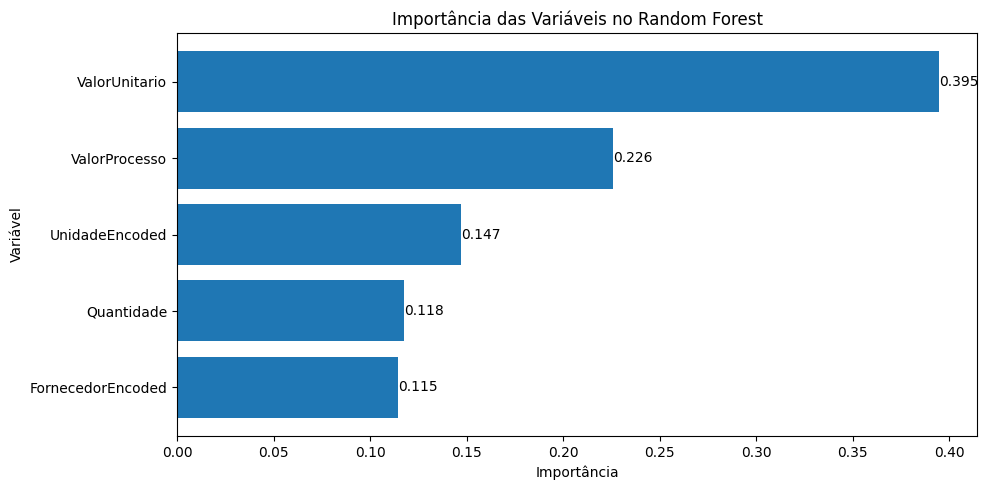

In [14]:
# ordena da maior para a menor importância
importancias_plot = (
    importancias
    .sort_values(
        by="Importancia",
        ascending=True
    )
)

plt.figure(figsize=(10,5))

plt.barh(
    importancias_plot["Variavel"],
    importancias_plot["Importancia"]
)

plt.xlabel("Importância")
plt.ylabel("Variável")

plt.title(
    "Importância das Variáveis no Random Forest"
)

# exibe valores ao lado das barras
for i, valor in enumerate(
    importancias_plot["Importancia"]
):
    plt.text(
        valor,
        i,
        f"{valor:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

*O modelo Random Forest foi utilizado para classificação supervisionada de processos potencialmente suspeitos. A base foi dividida aleatoriamente em 70% para treinamento e 30% para teste, permitindo avaliar a capacidade de generalização do modelo. O algoritmo calculou uma probabilidade de suspeição para cada processo, classificando-os em baixo, médio e alto risco.


O modelo Random Forest apresentou desempenho satisfatório na identificação de contratos com sinais de alerta, alcanando 94% de acurácia e ROC AUC de 0,93, indicando boa capacidade de separação entre registros suspeitos e não suspeitos. A inclusão das variáveis categóricas de fornecedor e unidade gestora contribuiu significativamente para a melhoria do modelo, permitindo capturar padrões comportamentais relacionados à concentração de contratos, recorrência de fornecedores e valores atípicos por órgão. Entre as variáveis mais relevantes destacaram-se ValorUnitario, ValorProcesso, UnidadeEncoded e FornecedorEncoded, demonstrando que tanto os aspectos financeiros quanto o contexto institucional influenciam na classificação dos contratos. O modelo também apresentou recall de 72% para a classe suspeita, mostrando boa capacidade de identificar contratos com indícios de anomalia, ainda que com presença de falsos positivos, o que é esperado em cenários de análise exploratória e detecção preventiva de riscos.

# Gráficos

## Valor do processo x Sobrepreço

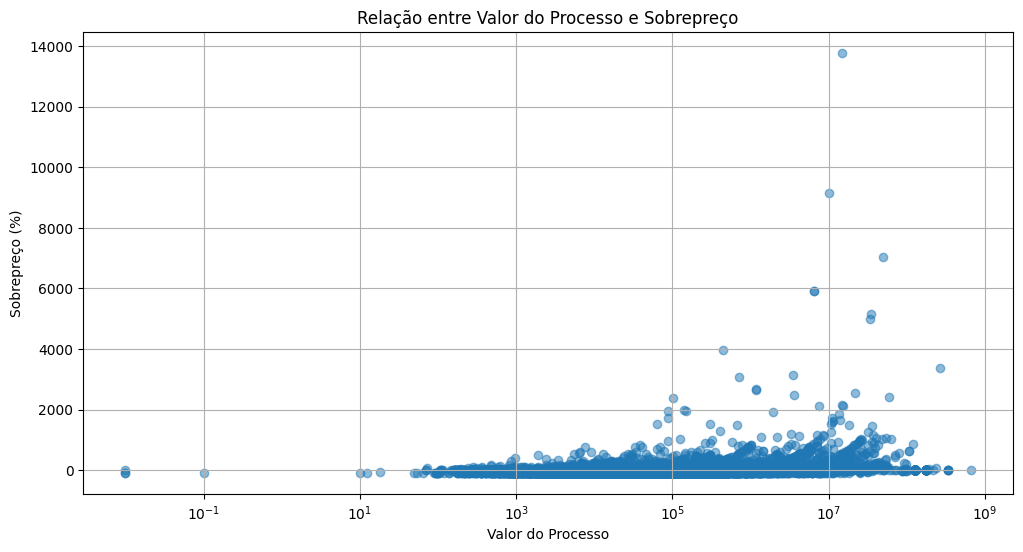

In [15]:
plt.figure(figsize=(12,6))

plt.scatter(
    df_modelo["ValorProcesso"],
    df_modelo["SobreprecoPercentual"],
    alpha=0.5
)

plt.xlabel("Valor do Processo")
plt.ylabel("Sobrepreço (%)")
plt.title("Relação entre Valor do Processo e Sobrepreço")

# escala log ajuda muito devido aos valores altos
plt.xscale("log")

plt.grid(True)

plt.show()

## Top 10 fornecedores

Linhas da base: 19676
Processos únicos: 11452

Registros após remoção de duplicidades: 11452


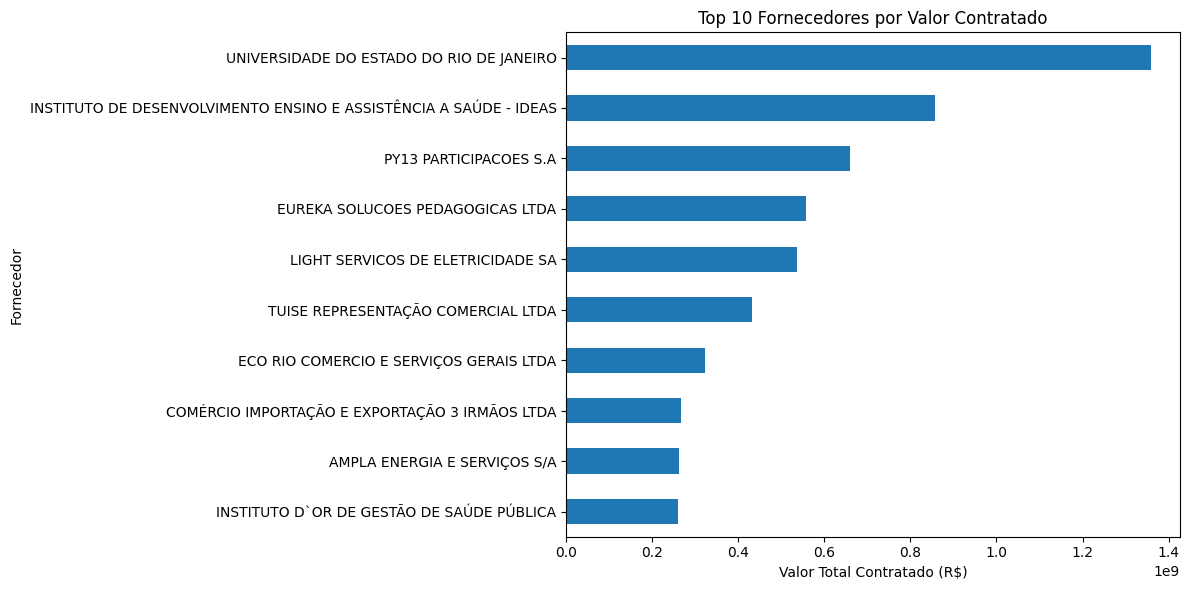

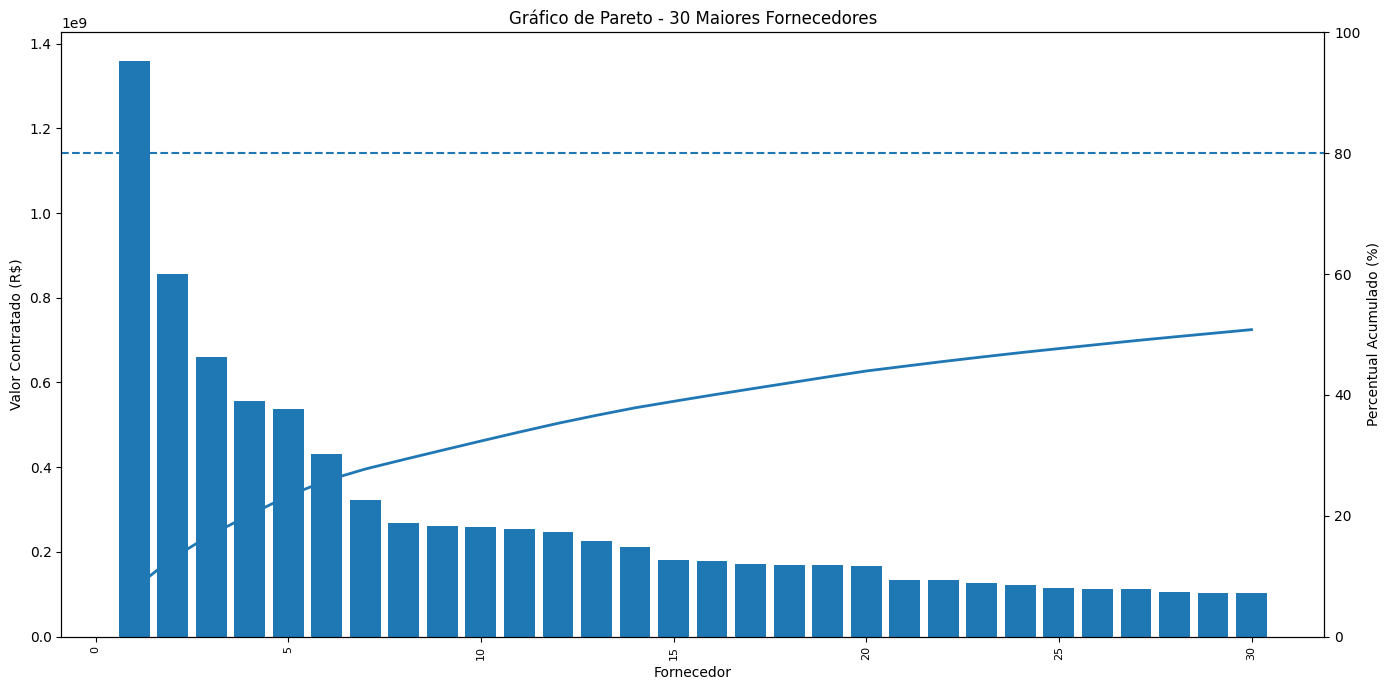

Os 30 maiores fornecedores representam 50.80% do valor total contratado.

TOP 10 FORNECEDORES:


,FornecedorVencedor,ValorProcesso
0,UNIVERSIDADE DO ESTADO DO RIO DE JANEIRO,"1,358,608,274.48"
1,INSTITUTO DE DESENVOLVIMENTO ENSINO E ASSISTÊN...,"855,923,442.79"
2,PY13 PARTICIPACOES S.A,"660,000,000.00"
3,EUREKA SOLUCOES PEDAGOGICAS LTDA,"556,948,085.33"
4,LIGHT SERVICOS DE ELETRICIDADE SA,"537,033,644.77"
5,TUISE REPRESENTAÇÃO COMERCIAL LTDA,"432,024,134.63"
6,ECO RIO COMERCIO E SERVIÇOS GERAIS LTDA,"322,677,174.48"
7,COMÉRCIO IMPORTAÇÃO E EXPORTAÇÃO 3 IRMÃOS LTDA,"267,611,952.41"
8,AMPLA ENERGIA E SERVIÇOS S/A,"261,812,589.26"
9,INSTITUTO D`OR DE GESTÃO DE SAÚDE PÚBLICA,"259,048,062.73"


In [16]:
# ------------------------------------------------------------
# DIAGNÓSTICO DA BASE
# ------------------------------------------------------------

print("Linhas da base:", len(df_limpo))
print("Processos únicos:", df_limpo["Processo"].nunique())

# ------------------------------------------------------------
# BASE DEDUPLICADA
# Mantém apenas uma ocorrência de cada processo
# ------------------------------------------------------------

base_fornecedores = (
    df_limpo[
        [
            "Processo",
            "FornecedorVencedor",
            "ValorProcesso"
        ]
    ]
    .drop_duplicates(
        subset=["Processo"]
    )
)

print(
    "\nRegistros após remoção de duplicidades:",
    len(base_fornecedores)
)

# ------------------------------------------------------------
# RANKING DE FORNECEDORES
# ------------------------------------------------------------

ranking_fornecedores = (
    base_fornecedores
    .groupby("FornecedorVencedor")["ValorProcesso"]
    .sum()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# TOP 10 FORNECEDORES
# ------------------------------------------------------------

top10 = ranking_fornecedores.head(10)

plt.figure(figsize=(12,6))

top10.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Fornecedores por Valor Contratado"
)

plt.xlabel("Valor Total Contratado (R$)")
plt.ylabel("Fornecedor")

plt.tight_layout()
plt.show()

# ============================================================
# PARETO DOS 30 MAIORES FORNECEDORES
# ============================================================

# Top 30 fornecedores por valor contratado
pareto = (
    ranking_fornecedores
    .head(30)
    .reset_index()
)

pareto.columns = [
    "Fornecedor",
    "Valor"
]

# Percentual em relação ao TOTAL GERAL
valor_total = ranking_fornecedores.sum()

pareto["Percentual"] = (
    pareto["Valor"]
    / valor_total
    * 100
)

pareto["PercentualAcumulado"] = (
    pareto["Percentual"]
    .cumsum()
)

# ------------------------------------------------------------
# GRÁFICO
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14,7))

ax1.bar(
    range(1, len(pareto)+1),
    pareto["Valor"]
)

ax1.set_ylabel("Valor Contratado (R$)")
ax1.set_xlabel("Fornecedor")

plt.xticks(
    rotation=90,
    fontsize=8
)

# Linha acumulada
ax2 = ax1.twinx()

ax2.plot(
    range(1, len(pareto)+1),
    pareto["PercentualAcumulado"],
    linewidth=2
)

ax2.axhline(
    y=80,
    linestyle="--"
)

ax2.set_ylabel("Percentual Acumulado (%)")
ax2.set_ylim(0,100)

plt.title(
    "Gráfico de Pareto - 30 Maiores Fornecedores"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# RESUMO
# ------------------------------------------------------------

percentual_top30 = (
    pareto["Valor"].sum()
    / valor_total
    * 100
)

print(
    f"Os 30 maiores fornecedores representam "
    f"{percentual_top30:.2f}% "
    f"do valor total contratado."
)
# ------------------------------------------------------------
# TABELA DOS 10 MAIORES
# ------------------------------------------------------------

print("\nTOP 10 FORNECEDORES:")

display(
    top10.reset_index()
)

## Pareto contratos acima R$ 10.000,00

Quantidade de contratos acima de R$ 10 milhões: 328
168 contratos representam aproximadamente 80% do valor contratado.


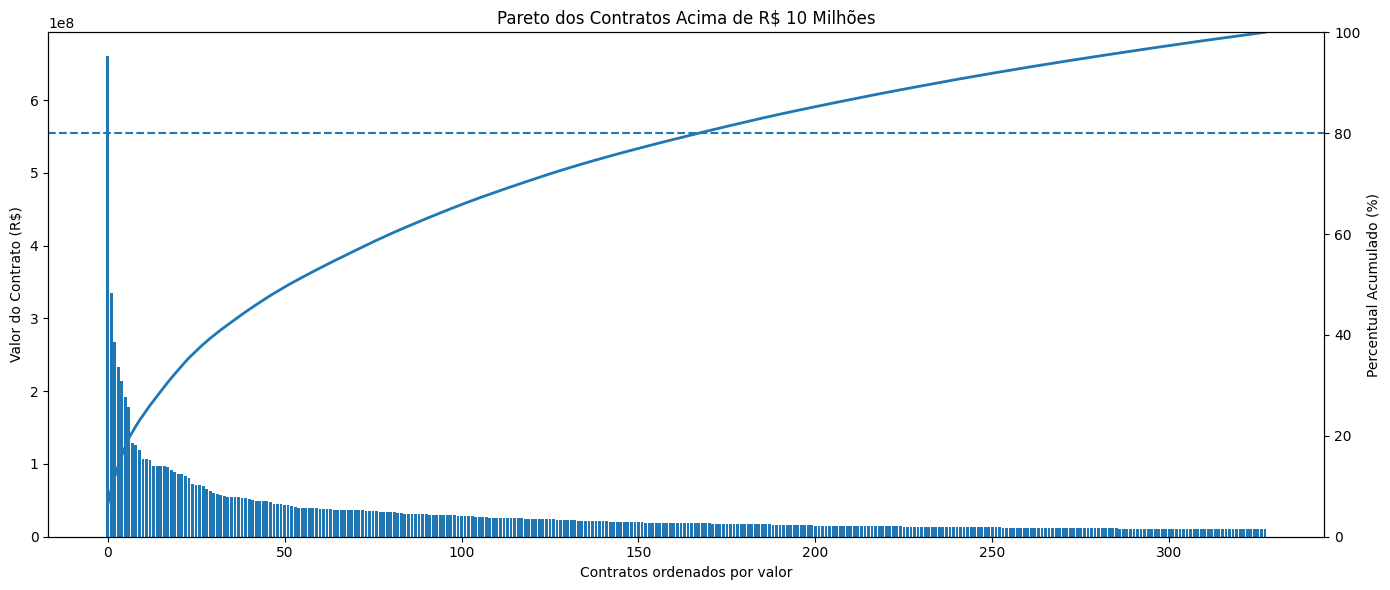


20 maiores contratos:


,Processo,FornecedorVencedor,ValorProcesso
7301,SEI-140001/078164/2024,PY13 PARTICIPACOES S.A,"660,000,000.00"
1767,SEI-030001/103373/A/2024,EUREKA SOLUCOES PEDAGOGICAS LTDA,"334,336,436.93"
7634,SEI-150016/022951/2024,COMÉRCIO IMPORTAÇÃO E EXPORTAÇÃO 3 IRMÃOS LTDA,"267,137,176.26"
3768,SEI-080001/002641/G/2022,INSTITUTO DE DESENVOLVIMENTO ENSINO E ASSISTÊN...,"233,750,626.08"
3963,SEI-080001/025088/2021,INSTITUTO DE DESENVOLVIMENTO ENSINO E ASSISTÊN...,"213,741,945.15"
3966,SEI-080001/025088C/2021,INSTITUTO DE DESENVOLVIMENTO ENSINO E ASSISTÊN...,"191,924,071.20"
2456,SEI-030029/015972/2023,EDITORA ROCCO LTDA,"178,097,063.55"
3871,SEI-080001/015269-D/2023,INSTITUTO D`OR DE GESTÃO DE SAÚDE PÚBLICA,"129,244,845.24"
1628,SEI-030001/069533/2024,EUREKA SOLUCOES PEDAGOGICAS LTDA,"125,949,837.44"
3874,SEI-080001/015269B/2023,INSTITUTO D`OR DE GESTÃO DE SAÚDE PÚBLICA,"119,316,525.12"


In [17]:
# ------------------------------------------------------------
# PROCESSOS ÚNICOS
# ------------------------------------------------------------

base_processos = (
    df_limpo[
        ["Processo", "FornecedorVencedor", "ValorProcesso"]
    ]
    .drop_duplicates(subset=["Processo"])
)

# ------------------------------------------------------------
# FILTRO > 10 MILHÕES
# ------------------------------------------------------------

contratos_grandes = (
    base_processos[
        base_processos["ValorProcesso"] >= 10_000_000
    ]
    .copy()
)

print(
    f"Quantidade de contratos acima de R$ 10 milhões: "
    f"{len(contratos_grandes)}"
)

# ------------------------------------------------------------
# ORDENAÇÃO
# ------------------------------------------------------------

contratos_grandes = contratos_grandes.sort_values(
    by="ValorProcesso",
    ascending=False
)

# ------------------------------------------------------------
# PARETO
# ------------------------------------------------------------

valor_total = contratos_grandes["ValorProcesso"].sum()

contratos_grandes["Percentual"] = (
    contratos_grandes["ValorProcesso"]
    / valor_total
    * 100
)

contratos_grandes["PercentualAcumulado"] = (
    contratos_grandes["Percentual"]
    .cumsum()
)

# ------------------------------------------------------------
# CONTRATOS NECESSÁRIOS PARA 80%
# ------------------------------------------------------------

contratos_80 = (
    contratos_grandes["PercentualAcumulado"]
    .lt(80)
    .sum()
    + 1
)

print(
    f"{contratos_80} contratos representam "
    f"aproximadamente 80% do valor contratado."
)

# ------------------------------------------------------------
# GRÁFICO
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(
    range(len(contratos_grandes)),
    contratos_grandes["ValorProcesso"]
)

ax1.set_xlabel(
    "Contratos ordenados por valor"
)

ax1.set_ylabel(
    "Valor do Contrato (R$)"
)

ax2 = ax1.twinx()

ax2.plot(
    range(len(contratos_grandes)),
    contratos_grandes["PercentualAcumulado"],
    linewidth=2
)

ax2.axhline(
    y=80,
    linestyle="--"
)

ax2.set_ylabel(
    "Percentual Acumulado (%)"
)

ax2.set_ylim(0,100)

plt.title(
    "Pareto dos Contratos Acima de R$ 10 Milhões"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# TOP 20 CONTRATOS
# ------------------------------------------------------------

print("\n20 maiores contratos:")

display(
    contratos_grandes[
        [
            "Processo",
            "FornecedorVencedor",
            "ValorProcesso"
        ]
    ]
    .head(20)
)

## BOXPLOT - DISPERSÃO DOS VALORES DOS PROCESSOS

Resumo Estatístico:
count        11,452.00
mean      1,487,226.50
std      10,112,431.05
min               0.01
25%          11,202.40
50%          52,500.00
75%         381,546.75
max     660,000,000.00
Name: ValorProcesso, dtype: float64


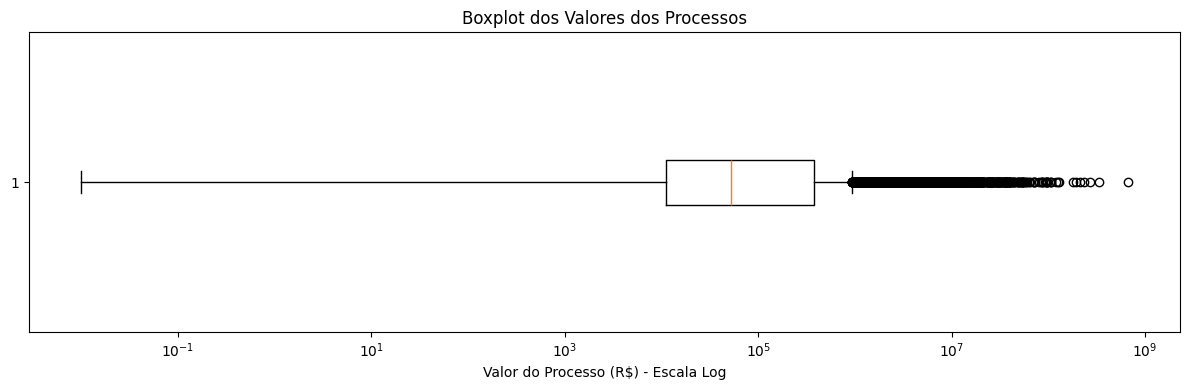


1º Quartil (Q1): R$ 11,202.40
Mediana:         R$ 52,500.00
3º Quartil (Q3): R$ 381,546.75


In [18]:
# ------------------------------------------------------------
# BASE COM PROCESSOS ÚNICOS
# ------------------------------------------------------------

base_processos = (
    df_limpo[
        ["Processo", "ValorProcesso"]
    ]
    .drop_duplicates(subset=["Processo"])
)

# ------------------------------------------------------------
# ESTATÍSTICAS
# ------------------------------------------------------------

q1 = base_processos["ValorProcesso"].quantile(0.25)
mediana = base_processos["ValorProcesso"].median()
q3 = base_processos["ValorProcesso"].quantile(0.75)

print("Resumo Estatístico:")
print(base_processos["ValorProcesso"].describe())

# ------------------------------------------------------------
# BOXPLOT Escala Logaritimica
# ------------------------------------------------------------

plt.figure(figsize=(12,4))

plt.boxplot(
    base_processos["ValorProcesso"],
    vert=False,
    showfliers=True
)

plt.xscale("log")

plt.xlabel("Valor do Processo (R$) - Escala Log")
plt.title("Boxplot dos Valores dos Processos")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# QUARTIS
# ------------------------------------------------------------

print(f"\n1º Quartil (Q1): R$ {q1:,.2f}")
print(f"Mediana:         R$ {mediana:,.2f}")
print(f"3º Quartil (Q3): R$ {q3:,.2f}")

Com base no boxplot dos valores de processos (em escala logarítmica), observa-se que 50% desses gastos concentram-se entre R\$ 11.202,40 e R\$ 381.546,75, com mediana de R\$ 52.500,00. A distribuição apresenta forte assimetria à direita, indicando que, embora a maioria dos processos tenha valores moderados, existem compras diretas com montantes extremamente elevados (próximos a bilhões de reais). A presença desses valores muito altos foge ao propósito típico da dispensa de licitação, sinalizando alertas para monitoramento.